# Test code to convert polygon pts to mask
**Notes**<br>
- plt.plot() plots a point (n,m) onto (n + 0.5, m + 0.5)
- Darwin expects a point (n,m) to plot onto (n,m)
- Therefore to accurately plot Darwin points using plt we need to subtract (0.5,0.5) from the point
<br><br>
- plt discretizes a pixel (n,m) to the rectangle region [n - 0.5, m - 0.5) to [n + 0.5, m + 0.5]
- Darwin discretizes a pixel to the rectangle region region [n, m] to [n+1, m+1]

<br>
In plt.imshow() you can use an extent parameter to specify the data-coordinate recatngle the entire image should occupy:<br>
  <XML>
  &nbsp;&nbsp;&nbsp;&nbsp;extent = (left, right, bottom, top)
  </XML>

- (left, top) is the origin
- (right, bottom) is the bottom right 

So to match the plt coordinate system to the darwin coordinate system us extent=(0,width,height,0); the default extent appears to be extent=(-0.5, width - 0.5, height - 0.5, -0.5)

In [122]:
from pathlib import Path
from joblib import Parallel, delayed


import json
import numpy as np
import matplotlib.pyplot as plt
import cv2

from scipy import stats
plt.style.use("dark_background")

In [ ]:
def load_polygons(json_path: Path) -> list[np.ndarray]:
    # Load JSON annotation
    with json_path.open("r") as f:
        annotation = json.load(f)

    # Extract all polygon paths from all annotations
    polygons = []

    for ann in annotation["annotations"]:
        polygon = ann.get("polygon")
        if polygon is None:
            continue

        for path in polygon.get("paths", []):
            points = np.asarray(
                [[vertex["x"], vertex["y"]] for vertex in path],
                dtype=np.float32,
            )

            if len(points) >= 3:
                polygons.append(points)
    return polygons


def get_polygon_bb(polygon: np.ndarray) -> dict[str, int]:
    y_min = int(np.floor(polygon[:, 1].min())) if polygon is not None else None
    y_max = int(np.ceil(polygon[:, 1].max())) if polygon is not None else None
    x_min = int(np.floor(polygon[:, 0].min())) if polygon is not None else None
    x_max = int(np.ceil(polygon[:, 0].max())) if polygon is not None else None

    y_min -= 4
    y_max += 4
    x_min -= 4
    x_max += 4
    result = {
        "y_min": y_min,
        "y_max": y_max,
        "x_min": x_min,
        "x_max": x_max,
    }
    return result


def contour_to_mask(
    contour, width, height, scale=16, threshold=0.5
) -> tuple[np.ndarray, np.ndarray]:
    """
    contour: Nx2 floating-point coordinates in the convention
             [0, width) x [0, height)
    """

    contour = np.asarray(contour, dtype=np.float32)

    hi_w = width * scale
    hi_h = height * scale

    # Coordinates remain in the same continuous system, scaled to subpixels
    pts = np.rint(contour * scale).astype(np.int32)

    highres = np.zeros((hi_h, hi_w), dtype=np.uint8)
    cv2.fillPoly(highres, [pts], 255)

    # Estimate fractional pixel coverage
    coverage = (
        cv2.resize(highres, (width, height), interpolation=cv2.INTER_AREA).astype(
            np.float32
        )
        / 255.0
    )

    # Binary majority-coverage mask
    mask = (coverage >= threshold).astype(np.uint8)

    return mask, coverage


def render_polygon(poly: np.ndarray, ax=None) -> None:
    if ax is None:
        ax = plt.gca()
    closed_poly = np.vstack([poly, poly[0]])
    ax.plot(closed_poly[:, 0], closed_poly[:, 1], "r-")
    for p in poly:
        ax.plot(p[0], p[1], "b.")


In [4]:
DIRECTORY = Path("/Users/jim/Documents/Archive")
IMG_DIR = DIRECTORY / "images"
JSON_DIR = DIRECTORY / "json"
assert IMG_DIR.exists(), f"Image directory {IMG_DIR} does not exist"
assert JSON_DIR.exists(), f"JSON directory {JSON_DIR} does not exist"

image_files = sorted(IMG_DIR.glob("*.png"))
json_files = sorted(JSON_DIR.glob("*.json"))

## Load an image and a polygon

In [ ]:
index = -1
image_path = image_files[index]
json_path = json_files[index]

# Load grayscale image
image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

height, width = image.shape

polygons = load_polygons(json_path)

# Order the polygons by area so we get the anodes first
polygon_areas = [cv2.contourArea(polygon.astype(np.float32)) for polygon in polygons]

ordered = sorted(
    zip(polygon_areas, polygons),
    key=lambda item: item[0],
    reverse=False,
)

polygon_areas = [area for area, _ in ordered]
polygons = [polygon for _, polygon in ordered]
print(f"Image shape: {image.shape}")
print(f"Loaded {len(polygons)} polygon(s)")


Image shape: (4332, 1340)
Loaded 4 polygon(s)


## Render the polygon and derived mask

Bounding box: y_min=2261, y_max=2301, x_min=836, x_max=876


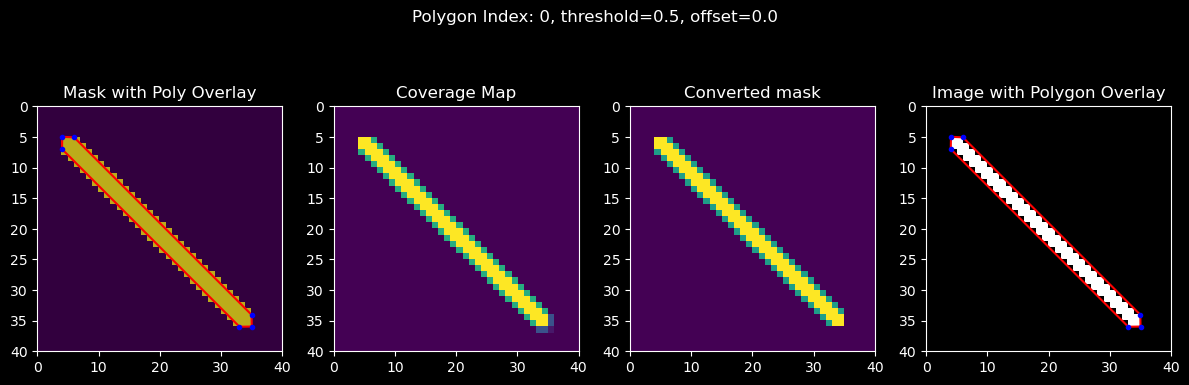

In [ ]:
# Select a polygon and crop the image around its bounding box
polygon_idx = 0
thresh = 0.5  # Threshold for the poly-fill coverage map
offset = 0.0  # Offset to explore coordinate offsets

poly = polygons[polygon_idx].copy()

# region get bounding box of the polygon and crop the image accordingly
bb = get_polygon_bb(poly)
y_min, y_max, x_min, x_max = bb["y_min"], bb["y_max"], bb["x_min"], bb["x_max"]
print(f"Bounding box: y_min={y_min}, y_max={y_max}, x_min={x_min}, x_max={x_max}")

# Update the polygon points to the cropped image coord reference
poly[:, 0] -= x_min
poly[:, 1] -= y_min
# endregion get bounding box and crop image

# Experiment with offsets
poly[:, 0] += offset
poly[:, 1] += offset

# Crop the image around the polygon's bounding box
cropped = image[y_min:y_max, x_min:x_max].copy()
cropped = ((cropped - cropped.min()) / (cropped.max() - cropped.min()) * 200 + 27) / 255

mask, coverage = contour_to_mask(
    poly, cropped.shape[1], cropped.shape[0], scale=4, threshold=thresh
)

fsize = (12, 4)
# region diplay graphs
extent = (0, cropped.shape[0], cropped.shape[1], 0)

fig, axes = plt.subplots(
    1, 4, figsize=fsize
)  # , gridspec_kw={'top': 0.94, 'right': 0.95, 'left': 0.05})
fig.suptitle(
    f"Polygon Index: {polygon_idx}, threshold={thresh}, offset={offset}", y=0.995
)

ax = axes[0]
ax.imshow(mask, cmap="viridis", alpha=0.75, extent=extent)
render_polygon(poly, ax=ax)
ax.set_title("Mask with Poly Overlay")

ax = axes[1]
ax.imshow(coverage, cmap="viridis", extent=extent)
# render_polygon(poly, ax=ax)
ax.set_title("Coverage Map")

ax = axes[2]
_tmp = mask.copy() + cropped
ax.imshow(_tmp, cmap="viridis", extent=extent)
ax.set_title("Converted mask")

ax = axes[3]
ax.imshow(cropped, cmap="gray", extent=extent)
render_polygon(poly, ax=ax)
ax.set_title(f"Image with Polygon Overlay")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
# endregion diplay graphs


## Test

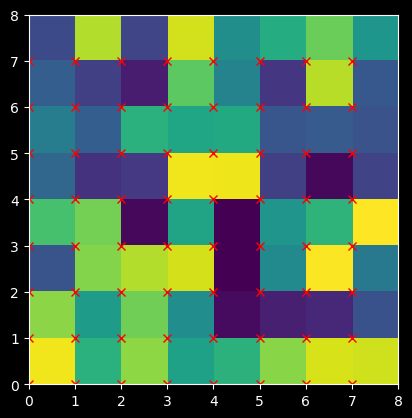

In [ ]:
_side = 8
np.random.seed(5)
_image = np.random.rand(_side, _side)
extent = (0, _image.shape[0], 0, _image.shape[1])
plt.imshow(_image, extent=extent)

offset = +0.0
for x in range(_side):
    for y in range(_side):
        plt.plot(x + offset, y + offset, "rx")
plt.show()

# Experiment in mask conversion 

Polygon area: 160.0
Mask area: 143
Coverage area: 160.29803466796875
Intersection area: 139.0196075439453
Polygon vs Mask IoU: 0.8477820650180363


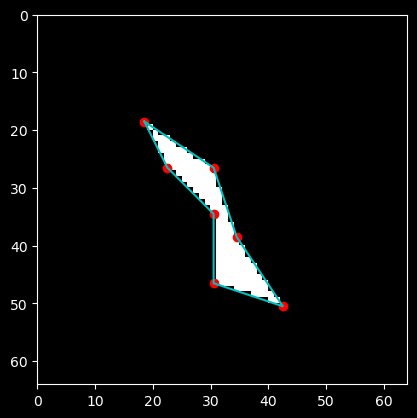

In [207]:
def poly_area(poly):
    return cv2.contourArea(poly)

def polygon_vs_mask_iou(poly, mask, coverage) -> float:
    mask = np.asarray(mask, dtype=bool)
    p_area = poly_area(poly)
    m_area = mask.sum()
    intersection_area = coverage[mask].sum()
    union_area = p_area + m_area - intersection_area
    return intersection_area / union_area if union_area > 0 else 0.0

_scale = 128
_surface = np.zeros((64, 64))
extent = (0, _surface.shape[0], _surface.shape[1],0)
_poly = np.array(((2, 4), (4, 7), (7,8), (10, 10), (9, 7), (6,7), (4,5)), dtype=np.float32) * 4 + np.array((10,2), dtype=np.float32)
_poly += (0.5,0.5)

_tmp = [(p[1], p[0]) for p in _poly]
_mask, _coverage = contour_to_mask(_tmp, _surface.shape[1], _surface.shape[0], scale=_scale, threshold=0.51)

_closed_poly = np.vstack([_poly, _poly[0]])

_area = poly_area(_poly)
_mask_area = _mask.sum()
_iou = polygon_vs_mask_iou(_poly, _mask, _coverage)

print(f"Polygon area: {_area}")
print(f"Mask area: {_mask_area}")
print(f"Coverage area: {_coverage.sum()}")
print(f"Intersection area: {( _coverage * _mask).sum()}")
print(f"Polygon vs Mask IoU: {_iou}")

plt.imshow(_surface, cmap="gray", extent=extent)
plt.imshow(_mask, cmap="gray", extent=extent)

for y, x in _poly:
    plt.plot(x, y, "ro")
plt.plot(_closed_poly[:, 1], _closed_poly[:, 0], "c-")
plt.show()


In [185]:
# Parallel computation of IoU for different offsets

def evaluate_shift(point_shifts):
    ious_for_shift = np.zeros((_intervals, _intervals), dtype=np.float32)

    for n in range(_intervals):
        for m in range(_intervals):
            grid_offset = (
                np.array((n / _intervals, m / _intervals), dtype=np.float32)
            )

            _poly_offset = _poly + grid_offset + point_shifts

            # contour_to_mask expects (x, y), while _poly is apparently (y, x)
            _tmp_offset = [(p[1], p[0]) for p in _poly_offset]

            _mask_offset, _coverage_offset = contour_to_mask(
                _tmp_offset,
                _surface.shape[1],
                _surface.shape[0],
                scale=_scale,
                threshold=0.5,
            )

            ious_for_shift[n, m] = polygon_vs_mask_iou(
                _poly_offset,
                _mask_offset,
                _coverage_offset,
            )

    return ious_for_shift

_intervals = 10
_ran_shifts = 1000
rng = np.random.default_rng(44)
# Apply the random shifts to be centered around zero.
randoms_shifts = rng.random((_ran_shifts, 2), dtype=np.float32) - np.array((0.5, 0.5), dtype=np.float32)
random_shifts = rng.random(size=_poly.shape, dtype=np.float32) - np.array((0.5, 0.5), dtype=np.float32)
# n_jobs=-1 uses all available CPU cores.
ious_per_shift = Parallel(n_jobs=16, prefer="processes")(
    delayed(evaluate_shift)(r_shift)
    for r_shift in randoms_shifts
)

_ious = np.mean(ious_per_shift, axis=0)
_stds = np.std(ious_per_shift, axis=0)

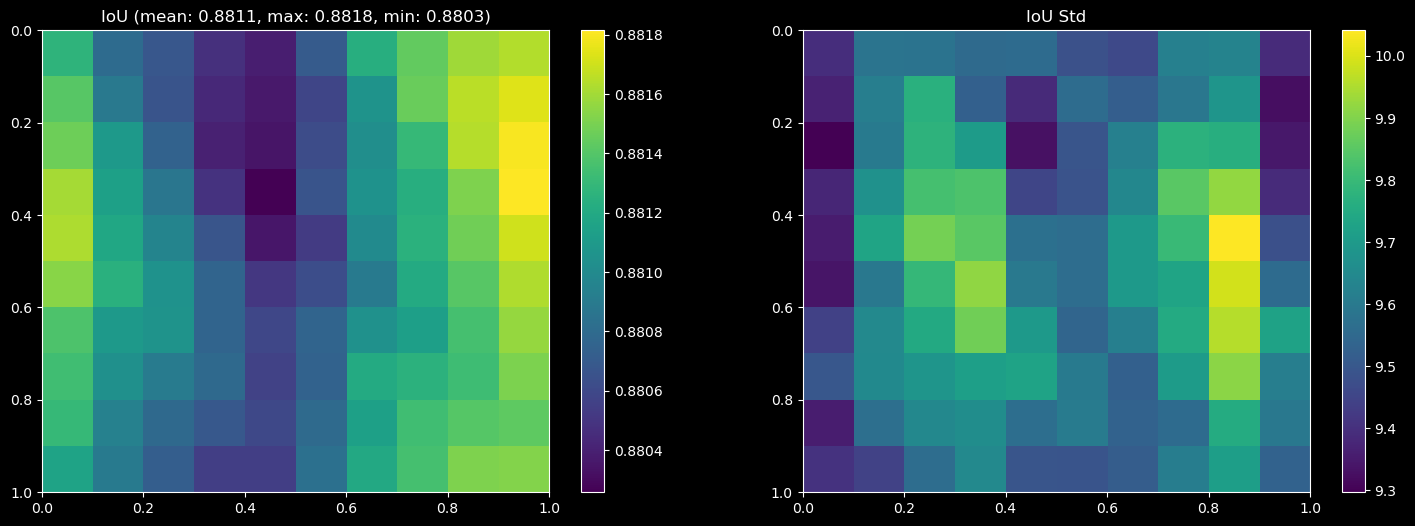

In [208]:
plt.figure(figsize=(18, 6))

plt.subplot(1,2,1)
plt.imshow(_ious, aspect='auto', extent=[0, _ious.shape[1]/_intervals, _ious.shape[0]/_intervals,0])
plt.colorbar()
plt.title(f"IoU (mean: {_ious.mean():.4f}, max: {_ious.max():.4f}, min: {_ious.min():.4f})")

plt.subplot(1,2,2)
plt.imshow(_stds*1000, aspect='auto', extent=[0, _stds.shape[1]/_intervals, _stds.shape[0]/_intervals,0])
plt.colorbar()
plt.title("IoU Std")

plt.show()

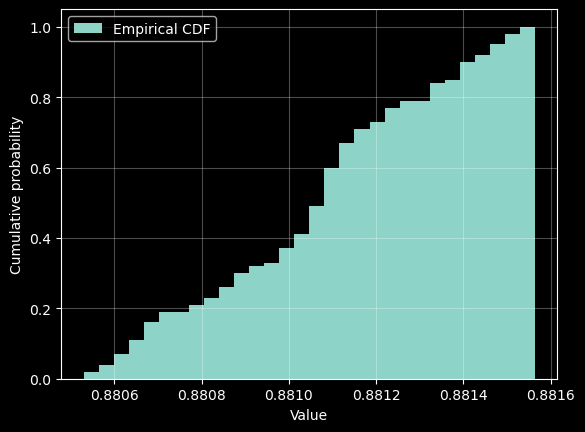

In [183]:
# Test for ious being uniformly random

values = _ious.ravel()

plt.hist(
    values,
    bins=30,
    density=True,
    cumulative=True,
    histtype="barstacked",
    label="Empirical CDF",
)

plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [184]:
from numpy.typing import ArrayLike

def uniform_fitted_bounds_test(
    values: ArrayLike,
    n_boot: int = 10_000,
    seed: int | None = 42,
) -> tuple[float, float, float, float]:
    """
    Test whether samples are consistent with a uniform distribution whose
    lower and upper bounds are estimated from the samples.

    The test uses a Kolmogorov-Smirnov statistic and a parametric bootstrap
    to account for fitting the uniform bounds from the same data. This is
    analogous in spirit to a Lilliefors correction.

    Parameters
    ----------
    values : ArrayLike
        One-dimensional array of observed numeric samples.
    n_boot : int, default=10_000
        Number of bootstrap samples used to estimate the p-value. Larger
        values produce a more precise p-value at greater computational cost.
    seed : int | None, default=42
        Seed for the random-number generator. Use an integer for reproducible
        bootstrap results, or ``None`` for non-reproducible sampling.

    Returns
    -------
    statistic : float
        Observed Kolmogorov-Smirnov statistic after fitting the uniform
        lower and upper bounds to ``values``.
    p_value : float
        Bootstrap p-value: the fraction of simulated fitted-uniform samples
        with a KS statistic at least as large as the observed statistic.
    low_fit : float
        Fitted lower bound of the uniform distribution, equal to
        ``min(values)``.
    high_fit : float
        Fitted upper bound of the uniform distribution, equal to
        ``max(values)``.

    Notes
    -----
    A large p-value means the sample is consistent with a uniform
    distribution with fitted bounds; it does not prove that the data are
    uniformly distributed.
    """
    values = np.asarray(values, dtype=float)

    if values.ndim != 1 or len(values) < 2:
        raise ValueError("values must be a one-dimensional array with at least two samples")
    if n_boot < 1:
        raise ValueError("n_boot must be at least 1")

    rng = np.random.default_rng(seed)

    low_fit = float(values.min())
    high_fit = float(values.max())

    if low_fit == high_fit:
        raise ValueError("values must contain at least two distinct values")

    normalized = (values - low_fit) / (high_fit - low_fit)
    statistic = float(stats.kstest(normalized, "uniform").statistic)

    simulated_statistics = np.empty(n_boot)
    n_samples = len(values)

    for i in range(n_boot):
        sample = rng.random(n_samples)
        normalized_sample = (
            (sample - sample.min()) / (sample.max() - sample.min())
        )
        simulated_statistics[i] = stats.kstest(
            normalized_sample, "uniform"
        ).statistic

    p_value = float(
        (np.sum(simulated_statistics >= statistic) + 1) / (n_boot + 1)
    )

    return statistic, p_value, low_fit, high_fit


D, p_value, low_fit, high_fit = uniform_fitted_bounds_test(values)

print(f"Fitted range: [{low_fit:.6f}, {high_fit:.6f}]")
print(f"Statistic:    {D:.4f}")
print(f"Bootstrap p:  {p_value:.4f}")

Fitted range: [0.880530, 0.881564]
Statistic:    0.1147
Bootstrap p:  0.1305


In [188]:
import numpy as np
from rasterio.features import rasterize
from affine import Affine


def polygon_to_mask(vertices_xy, shape):
    """
    vertices_xy : (N, 2) float array
        Polygon vertices in image coordinates (x, y).
        Integer coordinates are assumed to lie on pixel boundaries.

    shape : (height, width)

    Returns
    -------
    mask : bool ndarray, shape (height, width)
    """
    h, w = shape

    polygon = {
        "type": "Polygon",
        "coordinates": [np.asarray(vertices_xy, dtype=float).tolist()]
    }

    mask = rasterize(
        [(polygon, 1)],
        out_shape=(h, w),
        transform=Affine.identity(),
        fill=0,
        all_touched=True,
        dtype=np.uint8,
    )

    return mask.astype(bool)

def polygon_coverage(vertices_xy, shape, supersample=8):
    """
    Approximate fractional pixel coverage using supersampling.
    """
    h, w = shape
    s = supersample

    polygon = {
        "type": "Polygon",
        "coordinates": [
            (np.asarray(vertices_xy, dtype=float) * s).tolist()
        ]
    }

    hi = rasterize(
        [(polygon, 1)],
        out_shape=(h * s, w * s),
        transform=Affine.identity(),
        fill=0,
        all_touched=False,
        dtype=np.uint8,
    )

    # Average s x s subpixels belonging to each original pixel.
    coverage = hi.reshape(h, s, w, s).mean(axis=(1, 3))

    return coverage